# Intro

In this .ipynb, I first describe the "interpretation" of how the PWP3D and RBOT
papers calculate the derivatives of the signed distance transform. I then show
how their modelling is ideal (for background pixels, at least) if one assumes an orthographic projection.
I still need to investigate for a perspective projection.

While that shoots down some ideas I had for locally representing surface points
using quadrics, I still have a couple of other ideas for how they could help,
so I start by investigating the simple case of a cylinder. Later I will move onto
the harder quadrics.
 



# How the PWP3D/RBOT approximations work


I believe that the true value of $\frac{\partial \Phi}{\partial \xi}$ should be the negation of what the authors write, and that its missing negative sign would balance out the other one.
The physical/intuitive interpretation of how the algorithm works, at least for BG pixels, is as follows. We will just work with BG pixels for now to simplify some things (e.g., so that "signed distance" from the contour can be assumed to be positive, making it just "distance") and because the interpretation seems a bit more "sensible" for BG pixels; for FG pixels, because they use the 3D point "under" the current pixel rather than the 3D point "at" the nearest contour pixel for calculations, there are some parts that I cannot fully incorporate into this interpretation, nor do I have a better alternative one yet.

The RBOT paper represents $\mathbf{x}$ as a function $\mathbf{x}(\xi)$ of $\xi$, so that $\partial\mathbf{x} / \partial \xi$ is not 0 in general, and so that:

$$
\frac{\partial\Phi}{\partial \xi} = \frac{\partial \Phi}{\partial \mathbf{x}} \frac{\partial \mathbf{x}}{\partial \xi}
$$

However, I find it more intuitive to view $\mathbf{x}$ as constant, so that, not only do they not change colour (as in the previous, flawed interpretation) but they also do not change position in 2D/3D space either. Then we'd have $\partial \mathbf{x} / \partial \xi = 0$, and so that $\partial \Phi / \partial \xi \neq 0$, we'll instead represent $\Phi$ as a function of both $\mathbf{x}$ and $\xi$, i.e., $\Phi(\mathbf{x}, \xi)$. We'll also introduce a new function, $n(\mathbf{x}, \xi)$, which outputs the 2D coordinates of the nearest pixel to $\mathbf{x}$ on the silhouette contour for the pose $\xi$.
Lastly, we'll use angle brackets to denote normalization; that is, for a vector $\mathbf{v}$, we'll denote $\langle \mathbf{v} \rangle = \mathbf{v} / \lVert \mathbf{v} \rVert$.

Then, we can say that:
$$
\begin{aligned}
\Phi(\mathbf{x}, \xi)
    &= \lVert n(\mathbf{x}, \xi) - \mathbf{x} \rVert \\
    &= \sqrt{ (n_x(\mathbf{x}, \xi) - x)^2 + (n_y(\mathbf{x}, \xi) - y)^2} \\
\frac{\partial \Phi(\mathbf{x}, \xi)}{\partial \xi}
    &= \frac{\frac{\partial}{\partial \xi} \left((n_x(\mathbf{x}, \xi) - x)^2 + (n_y(\mathbf{x}, \xi) - y)^2\right)}{2\lVert n(\mathbf{x}, \xi) - \mathbf{x} \rVert}\\
    &= \frac{2((n_x(\mathbf{x}, \xi) - x)\frac{\partial n_x}{\partial \xi} + (n_y(\mathbf{x}, \xi) - y)\frac{\partial n_y}{\partial \xi} )}{2\lVert n(\mathbf{x}, \xi) - \mathbf{x} \rVert}\\
    &= \frac{(n(\mathbf{x}, \xi) - \mathbf{x})^T \, \frac{\partial n(\mathbf{x}, \xi)}{\partial \xi}}{\lVert n(\mathbf{x}, \xi) - \mathbf{x} \rVert}\\
    &= \langle \,n(\mathbf{x}, \xi) - \mathbf{x}\,\rangle^T\, \frac{\partial n(\mathbf{x}, \xi)}{\partial \xi}
\end{aligned}
$$

Assuming that a unique $n(\mathbf{x}, \xi)$ exists for $\mathbf{x}$, then $\frac{\partial \Phi}{\partial \mathbf{x}} = \nabla \Phi = \langle \,\mathbf{x} - n(\mathbf{x}, \xi) \,\rangle = -\langle \,n(\mathbf{x}, \xi) - \mathbf{x}\,\rangle$. Explanation/justification can be found [here](https://math.stackexchange.com/questions/2358675/gradient-of-the-distance-of-point-and-set) and [here](https://math.stackexchange.com/questions/693520/the-gradient-of-a-distance-function). Thus, the finite-difference-calculated $\frac{\partial \Phi(\mathbf{x})}{\partial \mathbf{x}}$ calculated in the RBOT paper is essentially the same as $-\langle \,n(\mathbf{x}, \xi) - \mathbf{x}\,\rangle$, which takes care of balancing out the other missing sign. And if you read through the RBOT code (in the `operator()` method of the `Parallel_For_computeJacobiansGN` class in `optimization_engine.h`), then you can see that what the RBOT paper reports as $\frac{\partial \mathbf{x}}{\partial \xi}$ (which they represent by the equivalent $\frac{\partial \pi}{\partial \xi}$, with $\pi$ being the projection function taking 3D points to 2D) is _actually_ just $\frac{\partial n}{\partial \xi}$ for BG pixels _so long as_ the following assumption is made.

The assumption is that WHICH 3D point on the model's surface becomes the nearest contour 2D point (under projection) to the (static) pixel $\mathbf{x}$ won't change, but that WHERE said 3D point is will change.

Viewed another way: it's like each pixel gets its own 1-point, radial SDT that it cares about. Or: it's like each pixel gets its own 1-vertex mesh that it is using to approximate the SDT derivatives.

Now, the interpretation for FG pixels is a bit less clear, since they assume the nearest point would move by the same amount as the 3D point hit by a ray through the current pixel, and I'm not sure when that would be more accurate than just using the same model as the BG... but nonetheless, even just having the intuition for the BG might help.

I _think_ my above interpretation/intuition is fairly decent, but maybe there's a better one; the authors never (as far as I can tell) clearly state that the above is being done, and further, the seemingly-mismatched sign stuff obscures such an interpretation.

I decided to, as a test, see what happens in the RBOT code if you use the closest contour xyz when looking at the FG in the same way they are used for getting 3D points for the BG. On some objects, like the cube, koala candy, etc., accuracy is increased, while for others, like the baking soda and clown, accuracy is decreased. In both cases, though, the difference was fairly small. I still need to test more before making statements about a pattern, but so far, it's more obviously the sharp-edged prism-like objects for whom accuracy increased.

<hr>

Anyway, to recap:

$$
\frac{\partial \Phi(\mathbf{x}, \xi)}{\partial \xi} = \langle \,n(\mathbf{x}, \xi) - \mathbf{x}\,\rangle^T\, \frac{\partial n(\mathbf{x}, \xi)}{\partial \xi}
$$

with the first vector in the dot product being already taken care of by the RBOT code. Now, what about the other vector, the $\frac{\partial n (\mathbf{x}, \xi)}{\partial \xi}$? Is there any way to take advantage of the single-point-model realization or to improve upon its accuracy or efficiency?
(Right now, it's like each BG pixel gets its own 1-point SDT that it cares about.)

Well, below I get some pretty convincing suggestions that this 1-point "simplification" actually generates the same results as "ground truth" assuming the derivative exists at all, so I don't think accuracy can be improved.

As for efficiency, I don't think this realization about how PWP3D/RBOT treat things really opens up any GPU optimizations/precomputations for their approach that I was not already in the process
of implementing via the mesh-based SDT approach; _maybe_ the fact that only the *unit* dir matters would let
me make a few more values constant rather than interpolated, but that's about it.

But maybe if I find out there is actually a difference for perspective projection, then the possibility of accuracy improvements will open up again.

Now-discarded ideas I had before I realized the derivative "approximation" is probably ideal:

- ~~Treating the silhouette as a set of infinitesimal points separated in space would not change anything, because
the derivative of the piecewise min() function would still just look at only the closest point in isolation.~~
- ~~Maybe a polyline would be slightly more accurate, or estimating local 2D curvature at each iteration, but any image processing becomes really expensive, especially on mobile. So it'd be better to precompute these values and store them in the mesh... at which point, it seems better to modify the sparse approach of SRT3D and the like instead of trying to find a better dense approach.~~

## Why does a "non-ideal" foreground modelling sometimes work better?

Regarding foreground vs. background pixels, I'm not sure why
the approach for foreground pixels works better with a non-ideal modelling for
some 3D objects. I need to see if it's due to perspective projection, or if maybe
it's because it's only "ideal" because I assume that the finite-difference SDT
derivative approximation they use is "close enough" to the theoretical ideal of
using the normal vector towards the nearest point (~~so I should test the effect
of normalizing the finite difference result and/or normalizing the dir to the
nearest contour pixel to see if that helps~~ UPDATE: see below for results on these). But maybe it's something else that
I do not understand.

I tested the result of normalizing the finite difference approximation as well
as normalizing the dir to the nearest contour pixel. Both lead to a decrease in
accuracy, especially the latter. For the latter, I can sort of see why for some
cases... if you have a straight edge at, let's say, a 45 degree angle, it's going
to have a jagged rasterization. For background pixels right along this edge,
the closest pixel will be either 1 to the side or 1 to the bottom (because both
are the same distance, so the tie will be broken arbitrarily). Thus, it will
give a gradient value that is either fully vertical or fully horizontal, whereas
the true gradient is angled by 45 degrees. So in this case, a finite difference
approximation is better. But as for normalization to unit length, I'm not sure
why that degrades performance... my only hypothesis at the moment is that maybe 
there are pixels for which the distance to the contour is zero and these should
be weighted less... but also not weighted zero, because when I test excluding
them, accuracy still degrades... yeah, I don't know. 


## Why this single-point "approximation" seems to give _exact_ results for the SDT gradient

Because a few test examples that I at first _thought_ would yield different results for the single-point approximation compared to the "ground truth" but did not in fact do so. Paired with some other thinking/tests outside of this notebook, I'm pretty sure none exist, at least for the orthographic projection that is being done here to simplify things.

Let's first start with the distance from a pixel to an infinitely-long straight line, and let's only worry about 2D motion for now. We'll parameterize the line by a point $(x_0, y_0)$ and a direction $\theta \in [0, 2\pi)$. We could, instead of $\theta$, use a 2nd point (four variables), but that makes setting a "fixed" point on the line harder, so sticking with three variables seems better.

The constant $(x_p, y_p)$ represents our pixel.


In [2]:
import numpy as np               # For fast floating-point array computations
import time                      # For getting CPU time & whatnot
import random
import matplotlib.pyplot as plt  # For graphs
import math                      # For non-symbolic math (like float sqrt)


# Sympy is the symbolic math library.
import sympy
from sympy import simplify, solve, Eq # Sympy functions we'll use especially often.

# For displaying math nicely
from IPython.display import display
sympy.init_printing()

x0, xp, y0, yp = sympy.symbols('x0, x_p, y0, y_p', real=True)
lambda0, lambda1 = sympy.symbols('lambda0, lambda1', real=True)


p0 = sympy.Matrix([x0, y0])
p1 = sympy.Matrix([xp, yp])

s0, s1 = sympy.symbols('s0, s1', real=True)#, positive=True)

theta = sympy.Symbol('theta', real=True)


In [3]:
const_subs = {x0: s0, y0: s1, theta: lambda0}
HR_STR2 = "---------------------------------------------------------------------"

c1x_near = 1 + sympy.cos(theta) # Assume radius == 1 w.l.o.g.
c1y_near = sympy.sin(theta)

c1_const_near = sympy.Matrix([c1x_near, c1y_near]).subs(const_subs)

cos_diff = sympy.cos(theta - const_subs[theta])
sin_diff = sympy.sin(theta - const_subs[theta])
c1x_const_near = cos_diff * c1_const_near[0] - sin_diff * c1_const_near[1]


c1_dist = (x0 + c1x_near - xp)**2

c1_const_dist = (x0 + c1x_const_near - xp)**2

display(simplify(c1_dist))

c1_grad = sympy.Matrix([sympy.diff(c1_dist, var) for var in [x0, y0, theta]])
display(simplify(c1_grad))


c1_const_grad = sympy.Matrix([sympy.diff(c1_const_dist, var) for var in [x0, y0, theta]])
display(simplify(c1_const_grad))

print(HR_STR2)
c1_grad_for_subs = c1_grad.subs(const_subs)
c1_const_grad_for_subs = c1_const_grad.subs(const_subs)
display(simplify(c1_grad_for_subs))
display(simplify(c1_const_grad_for_subs))

⎡   2⋅x₀ - 2⋅xₚ + 2⋅cos(θ) + 2   ⎤
⎢                                ⎥
⎢               0                ⎥
⎢                                ⎥
⎣2⋅(-x₀ + xₚ - cos(θ) - 1)⋅sin(θ)⎦

⎡          2⋅x₀ - 2⋅xₚ + 2⋅cos(θ) + 2⋅cos(λ₀ - θ)          ⎤
⎢                                                          ⎥
⎢                            0                             ⎥
⎢                                                          ⎥
⎣2⋅(-sin(θ) + sin(λ₀ - θ))⋅(x₀ - xₚ + cos(θ) + cos(λ₀ - θ))⎦

---------------------------------------------------------------------


⎡   2⋅s₀ - 2⋅xₚ + 2⋅cos(λ₀) + 2    ⎤
⎢                                  ⎥
⎢                0                 ⎥
⎢                                  ⎥
⎣2⋅(-s₀ + xₚ - cos(λ₀) - 1)⋅sin(λ₀)⎦

⎡   2⋅s₀ - 2⋅xₚ + 2⋅cos(λ₀) + 2    ⎤
⎢                                  ⎥
⎢                0                 ⎥
⎢                                  ⎥
⎣2⋅(-s₀ + xₚ - cos(λ₀) - 1)⋅sin(λ₀)⎦

In [4]:
display(simplify(c1_grad_for_subs - c1_const_grad_for_subs))

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

In [5]:
const_subs = {x0: s0, y0: s1, theta: lambda0}

fromCent = (p1 - p0).normalized()
c2diff = (p0 + fromCent - p1)
constC2diff = (p0 + fromCent.subs(const_subs) - p1)

c2nearest = c2diff.dot(c2diff)
constCNearest = constC2diff.dot(constC2diff) 

c2grad = sympy.Matrix([sympy.diff(c2nearest, var) for var in [x0, y0, theta]])
display(simplify(c2grad))


c2const_grad = sympy.Matrix([sympy.diff(constCNearest, var) for var in [x0, y0, theta]])
display(simplify(c2const_grad))

print(HR_STR2)
c2grad_for_subs = c2grad.subs(const_subs)
c2const_grad_for_subs = c2const_grad.subs(const_subs)
display(simplify(c2grad_for_subs))
display(simplify(c2const_grad_for_subs))

⎡                            2⋅x₀                                             
⎢2⋅x₀ - ────────────────────────────────────────────── - 2⋅xₚ + ──────────────
⎢          ___________________________________________             ___________
⎢         ╱   2               2     2               2             ╱   2       
⎢       ╲╱  x₀  - 2⋅x₀⋅xₚ + xₚ  + y₀  - 2⋅y₀⋅yₚ + yₚ            ╲╱  x₀  - 2⋅x₀
⎢                                                                             
⎢                            2⋅y₀                                             
⎢2⋅y₀ - ────────────────────────────────────────────── - 2⋅yₚ + ──────────────
⎢          ___________________________________________             ___________
⎢         ╱   2               2     2               2             ╱   2       
⎢       ╲╱  x₀  - 2⋅x₀⋅xₚ + xₚ  + y₀  - 2⋅y₀⋅yₚ + yₚ            ╲╱  x₀  - 2⋅x₀
⎢                                                                             
⎣                                                   

⎡  ⎛                        _________________________⎞⎤
⎢  ⎜                       ╱          2            2 ⎟⎥
⎢2⋅⎝-s₀ + xₚ + (x₀ - xₚ)⋅╲╱  (s₀ - xₚ)  + (s₁ - yₚ)  ⎠⎥
⎢─────────────────────────────────────────────────────⎥
⎢                _________________________            ⎥
⎢               ╱          2            2             ⎥
⎢             ╲╱  (s₀ - xₚ)  + (s₁ - yₚ)              ⎥
⎢                                                     ⎥
⎢  ⎛                        _________________________⎞⎥
⎢  ⎜                       ╱          2            2 ⎟⎥
⎢2⋅⎝-s₁ + yₚ + (y₀ - yₚ)⋅╲╱  (s₀ - xₚ)  + (s₁ - yₚ)  ⎠⎥
⎢─────────────────────────────────────────────────────⎥
⎢                _________________________            ⎥
⎢               ╱          2            2             ⎥
⎢             ╲╱  (s₀ - xₚ)  + (s₁ - yₚ)              ⎥
⎢                                                     ⎥
⎣                          0                          ⎦

---------------------------------------------------------------------


⎡                            2⋅s₀                                             
⎢2⋅s₀ - ────────────────────────────────────────────── - 2⋅xₚ + ──────────────
⎢          ___________________________________________             ___________
⎢         ╱   2               2               2     2             ╱   2       
⎢       ╲╱  s₀  - 2⋅s₀⋅xₚ + s₁  - 2⋅s₁⋅yₚ + xₚ  + yₚ            ╲╱  s₀  - 2⋅s₀
⎢                                                                             
⎢                            2⋅s₁                                             
⎢2⋅s₁ - ────────────────────────────────────────────── - 2⋅yₚ + ──────────────
⎢          ___________________________________________             ___________
⎢         ╱   2               2               2     2             ╱   2       
⎢       ╲╱  s₀  - 2⋅s₀⋅xₚ + s₁  - 2⋅s₁⋅yₚ + xₚ  + yₚ            ╲╱  s₀  - 2⋅s₀
⎢                                                                             
⎣                                                   

⎡  ⎛                        _________________________⎞⎤
⎢  ⎜                       ╱          2            2 ⎟⎥
⎢2⋅⎝-s₀ + xₚ + (s₀ - xₚ)⋅╲╱  (s₀ - xₚ)  + (s₁ - yₚ)  ⎠⎥
⎢─────────────────────────────────────────────────────⎥
⎢                _________________________            ⎥
⎢               ╱          2            2             ⎥
⎢             ╲╱  (s₀ - xₚ)  + (s₁ - yₚ)              ⎥
⎢                                                     ⎥
⎢  ⎛                        _________________________⎞⎥
⎢  ⎜                       ╱          2            2 ⎟⎥
⎢2⋅⎝-s₁ + yₚ + (s₁ - yₚ)⋅╲╱  (s₀ - xₚ)  + (s₁ - yₚ)  ⎠⎥
⎢─────────────────────────────────────────────────────⎥
⎢                _________________________            ⎥
⎢               ╱          2            2             ⎥
⎢             ╲╱  (s₀ - xₚ)  + (s₁ - yₚ)              ⎥
⎢                                                     ⎥
⎣                          0                          ⎦

In [6]:
display(simplify(c2const_grad_for_subs- c2grad_for_subs))

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

In [7]:
HR_STR = "---------------------------------------------------------------------"
ray_dir = sympy.Matrix([sympy.cos(theta), sympy.sin(theta)])
const_subs = {x0: s0, y0: s1, theta: lambda0}
projection_len = (p1 - p0).dot(ray_dir)
const_proj_len = projection_len.subs(const_subs)


nearest = p0 + projection_len * ray_dir
const_nearest = p0 + const_proj_len * ray_dir

diff = (nearest - p1)
dist = diff.dot(diff)

const_diff = (const_nearest - p1)
const_dist = const_diff.dot(const_diff)

display(simplify(nearest))
display(simplify(dist))

grad = sympy.Matrix([sympy.diff(dist, var) for var in [x0, y0, theta]])
display(simplify(grad))


const_grad = sympy.Matrix([sympy.diff(const_dist, var) for var in [x0, y0, theta]])
display(simplify(const_grad))

print(HR_STR)
grad_for_subs = grad.subs(const_subs)
const_grad_for_subs = const_grad.subs(const_subs)
display(simplify(grad_for_subs))
display(simplify(const_grad_for_subs))

⎡x₀ - ((x₀ - xₚ)⋅cos(θ) + (y₀ - yₚ)⋅sin(θ))⋅cos(θ)⎤
⎢                                                 ⎥
⎣y₀ - ((x₀ - xₚ)⋅cos(θ) + (y₀ - yₚ)⋅sin(θ))⋅sin(θ)⎦

⎡                                                     -x₀⋅cos(2⋅θ) + x₀ + xₚ⋅c
⎢                                                                             
⎢                                                     -x₀⋅sin(2⋅θ) + xₚ⋅sin(2⋅
⎢                                                                             
⎢  2                                                                       2  
⎣x₀ ⋅sin(2⋅θ) - 2⋅x₀⋅xₚ⋅sin(2⋅θ) - 2⋅x₀⋅y₀⋅cos(2⋅θ) + 2⋅x₀⋅yₚ⋅cos(2⋅θ) + xₚ ⋅s

os(2⋅θ) - xₚ - y₀⋅sin(2⋅θ) + yₚ⋅sin(2⋅θ)                                      
                                                                              
θ) + y₀⋅cos(2⋅θ) + y₀ - yₚ⋅cos(2⋅θ) - yₚ                                      
                                                                              
                                                  2                           
in(2⋅θ) + 2⋅xₚ⋅y₀⋅cos(2⋅θ) - 2⋅xₚ⋅yₚ⋅cos(2⋅θ) - y₀ ⋅sin(2⋅θ) + 2⋅y₀⋅yₚ⋅sin(2⋅θ

                ⎤
                ⎥
              

⎡             2⋅x₀ - 2⋅xₚ - 2⋅((s₀ - xₚ)⋅cos(λ₀) + (s₁ - yₚ)⋅sin(λ₀))⋅cos(θ)  
⎢                                                                             
⎢             2⋅y₀ - 2⋅yₚ - 2⋅((s₀ - xₚ)⋅cos(λ₀) + (s₁ - yₚ)⋅sin(λ₀))⋅sin(θ)  
⎢                                                                             
⎣2⋅((s₀ - xₚ)⋅cos(λ₀) + (s₁ - yₚ)⋅sin(λ₀))⋅(x₀⋅sin(θ) - xₚ⋅sin(θ) - y₀⋅cos(θ) 

            ⎤
            ⎥
            ⎥
            ⎥
+ yₚ⋅cos(θ))⎦

---------------------------------------------------------------------


⎡                                                        -s₀⋅cos(2⋅λ₀) + s₀ - 
⎢                                                                             
⎢                                                        -s₀⋅sin(2⋅λ₀) + s₁⋅co
⎢                                                                             
⎢  2                                                                          
⎣s₀ ⋅sin(2⋅λ₀) - 2⋅s₀⋅s₁⋅cos(2⋅λ₀) - 2⋅s₀⋅xₚ⋅sin(2⋅λ₀) + 2⋅s₀⋅yₚ⋅cos(2⋅λ₀) - s

s₁⋅sin(2⋅λ₀) + xₚ⋅cos(2⋅λ₀) - xₚ + yₚ⋅sin(2⋅λ₀)                               
                                                                              
s(2⋅λ₀) + s₁ + xₚ⋅sin(2⋅λ₀) - yₚ⋅cos(2⋅λ₀) - yₚ                               
                                                                              
 2                                                       2                    
₁ ⋅sin(2⋅λ₀) + 2⋅s₁⋅xₚ⋅cos(2⋅λ₀) + 2⋅s₁⋅yₚ⋅sin(2⋅λ₀) + xₚ ⋅sin(2⋅λ₀) - 2⋅xₚ⋅yₚ

                          ⎤
                      

⎡               2⋅s₀ - 2⋅xₚ - 2⋅((s₀ - xₚ)⋅cos(λ₀) + (s₁ - yₚ)⋅sin(λ₀))⋅cos(λ₀
⎢                                                                             
⎢               2⋅s₁ - 2⋅yₚ - 2⋅((s₀ - xₚ)⋅cos(λ₀) + (s₁ - yₚ)⋅sin(λ₀))⋅sin(λ₀
⎢                                                                             
⎣2⋅((s₀ - xₚ)⋅cos(λ₀) + (s₁ - yₚ)⋅sin(λ₀))⋅(s₀⋅sin(λ₀) - s₁⋅cos(λ₀) - xₚ⋅sin(λ

)               ⎤
                ⎥
)               ⎥
                ⎥
₀) + yₚ⋅cos(λ₀))⎦

In [8]:
sample_sit = {s0: 1, s1: 10, lambda0: -sympy.pi/6, xp: 0, yp: -1}

display(simplify(grad_for_subs.subs(sample_sit)))
display(simplify(const_grad_for_subs.subs(sample_sit)))



⎡ 1   11⋅√3 ⎤
⎢ ─ + ───── ⎥
⎢ 2     2   ⎥
⎢           ⎥
⎢  √3   33  ⎥
⎢  ── + ──  ⎥
⎢  2    2   ⎥
⎢           ⎥
⎣-11 + 60⋅√3⎦

⎡ 1   11⋅√3 ⎤
⎢ ─ + ───── ⎥
⎢ 2     2   ⎥
⎢           ⎥
⎢  √3   33  ⎥
⎢  ── + ──  ⎥
⎢  2    2   ⎥
⎢           ⎥
⎣-11 + 60⋅√3⎦

In [9]:
display(simplify(grad_for_subs - const_grad_for_subs))

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

Well, damn it. It looks like 2D translation/rotation for a line is already perfectly simulated at the point of interest by just looking at the nearest point.

I still need to test the effect of perspective projection (right now, this has just been looking at orthographic projection).

Even just for the orthographic case, though, it seems like it'd be worth mentioning in the thesis (or, if not there, some blog post) and for finding a proof of the general case. I'm 99% sure that one would already exist and just need to be cited; for finding such a citation, I think that asking some Math StackExchange site or subreddit might be easier than trying to scour Google scholar for a combination of search terms that, by themselves, would each yield thousands of unrelated results... And I have no faith in a LLM to help with this search either, unfortunately.


### Overestimating/Underestimating

The below, older idea is struck out because of the above realization.

~~If the single-point approximation isn't already perfect, then I need to confirm this next thought, but I think the PWP3D/RBOT version never really _underestimates_ the distance derivative magnitude; it can only ever _overestimate_, because the existence of other points will never _increase_ the true distance. Not sure if there's any value to this realization, though...~~

## Considering the Perspective Case

The simplest case to consider first is probably an infinite edge in 3D.
Parametrizing this will be a bit ugly in 3D compared to 2D. I still would prefer
a minimal parametrization so that I do not need to invoke Lagrange multipliers
or similar, though perhaps that will still end up looking nicer.

Once again, a 3D point/translation will be part of the parametrization. You could
technically use a 2D point if you ignore all lines that lie in one particular
plane, but I want to consider how movement along the line's direction vector
would compare in the single-point vs. ground truth case, so a 3D position is required.

I guess I'll start by trying spherical coordinates.

Then, for considering min distance to a pixel, we actually need to consider
min distance to a line through the pixel from the camera pinhole. So
that will be a single 3D point I guess (x, y, focal length); normalization is
not important.

In [22]:
import numpy as np               # For fast floating-point array computations
import time                      # For getting CPU time & whatnot
import random
import matplotlib.pyplot as plt  # For graphs
import math                      # For non-symbolic math (like float sqrt)


# Sympy is the symbolic math library.
import sympy
from sympy import simplify, solve, Eq # Sympy functions we'll use especially often.

# For displaying math nicely
from IPython.display import display
sympy.init_printing()

x0, xp, y0, yp, z0 = sympy.symbols('x0, x_p, y0, y_p, z0', real=True)

pointOnLine = sympy.Matrix([x0, y0, z0])
zp = 1
pixelCoord3D = sympy.Matrix([xp, yp, zp]) # zp is more of a focal length
pixel2D = sympy.Matrix([xp, yp])

# s0, s1 = sympy.symbols('s0, s1', real=True, positive=True)

theta, phi = sympy.symbols('theta, phi', real=True)

# "Constant" parameters for the edge's *current* pose.
xc, yc, zc, theta_c, phi_c = sympy.symbols("x_c, y_c, z_c, theta_c, phi_c")



In [11]:
HR_STR = "---------------------------------------------------------------------"

ray_dir_3D = sympy.Matrix([
    sympy.cos(phi) * sympy.cos(theta),
    sympy.cos(phi) * sympy.sin(theta),
    sympy.sin(phi)
])

def persp_proj(pt3D):
    z = pt3D[2]
    return sympy.Matrix([pt3D[0]/z, pt3D[1]/z])

const_subs_3D = {x0: xc, y0: yc, z0: zc, theta: theta_c, phi: phi_c}

# The minimum distance in 2D is not _necessarily_ the minimum distance in 3D.
# Well, maybe it is, because the only counter-example I can think of off-hand is
# the case of parallel lines, but I don't have a proof yet either that they are
# the same, so I'm going to assume otherwise for now.
# Even if it is the same for lines, though, it's definitely not true for all shapes in general.
tp = sympy.Symbol("t_p", real=True, positive=True)
t0 = sympy.Symbol("t0", real=True)

new_line_pt = pointOnLine + t0 * ray_dir_3D

disp_2D = persp_proj(new_line_pt) - pixel2D
display(simplify(disp_2D))

⎡t₀⋅cos(φ)⋅cos(θ) + x₀ - xₚ⋅(t₀⋅sin(φ) + z₀)⎤
⎢───────────────────────────────────────────⎥
⎢               t₀⋅sin(φ) + z₀              ⎥
⎢                                           ⎥
⎢t₀⋅sin(θ)⋅cos(φ) + y₀ - yₚ⋅(t₀⋅sin(φ) + z₀)⎥
⎢───────────────────────────────────────────⎥
⎣               t₀⋅sin(φ) + z₀              ⎦

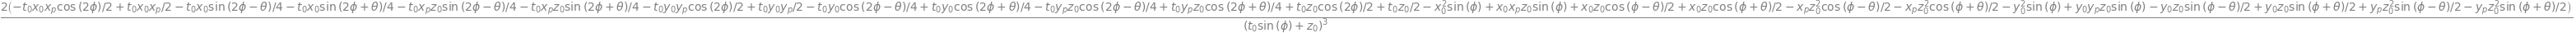

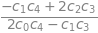

In [17]:
dist_sq_2D = simplify(disp_2D.dot(disp_2D))

firstPart = ((t0 * sympy.cos(phi))**2 + x0**2 + y0**2 + 2*t0*sympy.cos(phi)*(x0 * sympy.cos(theta) + y0 * sympy.sin(theta)))/(t0 * sympy.sin(phi) + z0)**2
secondPart = xp**2 + yp**2 - 2 * (xp*(t0*sympy.cos(phi)*sympy.cos(theta) + x0) + yp*(t0 * sympy.cos(phi)*sympy.sin(theta) + y0))/(t0 * sympy.sin(phi) + z0)
manual_dist_sq_2D = simplify(firstPart + secondPart)
if simplify(dist_sq_2D - manual_dist_sq_2D) != 0:
    raise Exception("Screwed up manual simplification!")
manual_numerator = simplify(manual_dist_sq_2D * (t0*sympy.sin(phi) + z0)**2)



display(sympy.collect(sympy.expand(manual_numerator), t0))
deriv_2D = simplify(sympy.diff(manual_dist_sq_2D, t0))
display(deriv_2D)



Number of solutions for more abstract test: 1


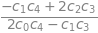

In [21]:
c0, c1, c2, c3, c4 = sympy.symbols("c0, c1, c2, c3, c4", real=True)

testEq = (c0*t0**2 + c1*t0 + c2)/(c3*t0 + c4)**2
testEqDiff = sympy.diff(testEq, t0)

# print("testEqDiff:")
# display(testEqDiff)

solnTest = sympy.solve(testEqDiff, [t0])
print("Number of solutions for more abstract test:", len(solnTest))
display(simplify(solnTest[0]))

In [23]:
soln = sympy.solve(deriv_2D, [t0])


Number of solutions: 1


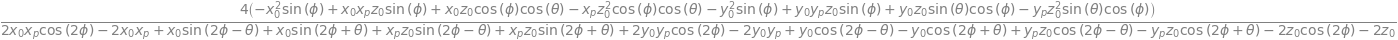

In [24]:
print("Number of solutions:", len(soln))
display(simplify(soln[0]))

In [27]:
const_t0 = soln[0].subs(const_subs_3D)


nearest_3D = pointOnLine + soln[0] * ray_dir_3D
const_nearest_3D = pointOnLine + const_t0 * ray_dir_3D

dist_persp = persp_proj(nearest_3D) - pixel2D
const_dist_persp = persp_proj(const_nearest_3D) - pixel2D

grad_persp = sympy.Matrix([sympy.diff(dist_persp, var) for var in const_subs_3D.keys()])
#display(simplify(grad_persp))


const_grad_persp = sympy.Matrix([sympy.diff(const_dist_persp, var) for var in const_subs_3D.keys()])
#display(simplify(const_grad_persp))

print(HR_STR)
grad_for_subs_persp = grad_persp.subs(const_subs_3D)
const_grad_for_subs_persp = const_grad_persp.subs(const_subs_3D)
#display(simplify(grad_for_subs_persp))
#display(simplify(const_grad_for_subs_persp))

---------------------------------------------------------------------


In [31]:
for _ in range(10):
    rands_dict = dict()
    for k in const_subs_3D.keys():
        rands_dict[const_subs_3D[k]] = random.random()
    rands_dict[xp] = random.random()
    rands_dict[yp] = random.random()
    diff_eval = (grad_for_subs_persp - const_grad_for_subs_persp).evalf(subs=rands_dict)
    print(diff_eval)    

Matrix([[0.279409637405022], [-0.286835574771779], [-0.0380740469409566], [0.0390859500753952], [-0.0422651316556309], [0.0433884222600187], [0.728487602180915], [-0.747848792999157], [-0.214946851301981], [0.220659545644862]])
Matrix([[4.08765929544543], [5.67505756788329], [6.29896819685018], [8.74510436210302], [-7.92230719876804], [-10.9988495062590], [-0.274575449770889], [-0.381203855691560], [5.86879108824581], [8.14787262646508]])
Matrix([[0.00727963450983544], [-0.0406749600266804], [0.0311156074869340], [-0.173858466249500], [-0.00941746104560679], [0.0526200664422554], [0.122770405315959], [-0.685979676855899], [0.0388300820124260], [-0.216963094995254]])
Matrix([[-1.35476341255984], [-1.29278627628787], [-1.34223312483126], [-1.28082921879483], [0.751000939046183], [0.716644469785107], [0.163388111498061], [0.155913502162102], [-0.369708779925010], [-0.352795501029279]])
Matrix([[-2.14682992536299], [-0.788065200062029], [-0.902875554404465], [-0.331430448218932], [0.567507

## Things to still try

- Because the gradients of the single-point assumption and the true shapes are only the same at the current pose, but not in general, perhaps the Hessians would differ? Looking at the Hessians with quadrics could really balloon the complexity and operation count, since current state of the art just approximates it using the gradient anyway. But maybe the single-point realization would allow for a compromise in Hessian complexity?
- See if perspective projection changes anything.
- Look for a proof; perhaps asking online for where to find one is a good idea.
- There are still other non-gradient areas where I think a local approximation
  could be useful for the sparse case, though maybe not for "dense" versions like RBOT and PWP3D anymore. 

# Principal Curvatures: cylinder case

Let's see if there's any way we can make use of local principal curvatures.

We will start by assuming the cylindrical case, for two reasons:

First, the math is a lot simpler, so it'll give a better idea of feasibility before we go too far.

Second, as the various "large displacement" papers showed, it's mostly the "out-of-frame" rotations that SRT3D sometimes struggles with. So even though curvature would still improve the realism of the "2D" derivative approximations in some cases, perhaps only considering the "out of frame" curvature would be a good compromise to consider.


## The math for the cylinder case

### Projection and Further Approximation
To save on some typesetting, I'll use "p" instead of $\xi$ below.

The unit dir to the nearest point is already accurate/efficient from the old methods (both sparse and dense), so we just need to worry about "dn/dp".

Now... there's a slight complication in that the closest point in 2D is not necessarily the same as the closest point in 3D.

Consider, for example, a camera ray through the image centre and a cylinder that's aligned with the camera but shifted to the right. Even though infinitely many cylinder points are the same shortest 3D distance from the ray, in 2D, the points further away from the camera will seem closer to the centre pixel.

This presents multiple problems... if we assume infinite cylinders, then there are cases like this where the shortest length is undefined (or, I guess, zero, if you consider limits). Finite cylinders add extra complexity, even if just for finding out what height of one should be.

So, should we just find the closest 3D point, and then project, as an approximation? Or should we look directly at what optimizes the perspective projection distance?

Let's start with the first, because it seems a bit simpler. And hey, maybe minimizing "nearest 3D distance" could end up being better in the long run anyway, by certain metrics? I mean, if one part of an object is much closer to the camera than another, the closer part could have way more "redundant" pixels that dominate the error and gradient sums, so maybe this unbalanced weighting could be counteracted by considering 3D distance. 



### The projection-delaying approximation:

Let's call "z" the nearest 3D point (to a line going from the camera through the pixel), let L(x,y) be this line, and use "P" for projection (just to reduce tex-ing at the moment).

Then:
```
n(x,y,p) = P(z(L(x,y), p))

dn/dp = dP/dz dz/dp
```

The dP/dz is already derived in the other papers. So we just have a... "fancier" dz/dp to find.

Let's first just consider a stationary cylinder with radius "r" and unit dir "v". let's give the line a point "q" and unit dir "u".

What we're really looking for, then, is the closest point on
[finish this later]

### The exact projection-based calculation:

Assuming an infinite cylinder, what does the contour look like after perspective projection? Obviously, just two straight lines. And in our case, we only care about one of those lines.

So, finding the closest point on a 2D line to a point is quite straight-forward. The question is how to get this line from a cylinder and pose, and what the derivatives are after.

If the cylinder were z-axis-aligned, then its parametric form is:
`(x - a)^2 + (y - b)^2 - r^2 = 0`.

If we let I2 be a 2x2 identity matrix , and we let "x" be the vector `[x, y]`, and finally we let alpha be the vector `[a, b]`, then this is just `x^T A x - 2*dot(alpha, x) + a^2 + b^2 - r^2 = 0`.

If we consider points along a ray `(e + t*u)`, but just the xy component so that it is 2D, then this is



(Rx + alpha)^T P (Rx + alpha) - r^2 = 0

x^t (R^t P R) x + 2 alpha^T P R x + a^2 + b^2 - r^2


In [ ]:
https://www.cambridge.org/core/services/aop-cambridge-core/content/view/B131C04079690F5EB1546800889A03DE/S1757748900001961a.pdf/div-class-title-principal-radii-of-curvature-at-a-point-on-an-ellipsoid-div.pdf

https://www.eecg.toronto.edu/~pagiamt/kcsmith/00169661.pdf

(("lines of curvature" OR "curvature lines") AND ("mesh" OR "tris" OR "triangular" OR "polygonal"))



SyntaxError: invalid decimal literal (1343814663.py, line 3)